In [ ]:
include("src/lvmodel.jl")
include("src/sampler.jl")
const GRB_ENV = Gurobi.Env(output_flag=0)

Set parameter Username
Set parameter LicenseID to value 2628089
Academic license - for non-commercial use only - expires 2026-02-25


hr_sample! (generic function with 1 method)

In [4]:
using Polyhedra
using QHull

Sinds = 0.001:0.25:4.0
vols = []  # Store volumes for each seed

for seed in [10, 20, 30]
    vols_seed = Float64[]  # Ensure this is a list for each seed
    for Sind in Sinds
        ep = create_energy_problem(4, Sind, seed=seed)
        samp = create_sampler(ep)
        is_feasible = warmup!(samp)
        if is_feasible == :Infeasible
            push!(vols_seed, 0.0)  # Ensure we push to the correct structure
            continue
        end
        trajectory = hr_sample!(samp, 10000)
        M = Matrix(trajectory')
        efd = vrep(M)
        p = polyhedron(efd, QHull.Library())
        removevredundancy!(p)
        push!(vols_seed, volume(p))
    end
    push!(vols, vols_seed)  # Push the entire vector to store structured results
end

In [7]:
bls = []  # Store baseline supply for each seed
for seed in [10, 20, 30]
    ep = create_energy_problem(4, 1.0, seed=seed)
    push!(bls, baseline_supply(ep))
end

In [8]:
bls

3-element Vector{Any}:
 1.013134234319145
 1.1708143535423163
 1.0686970275884828

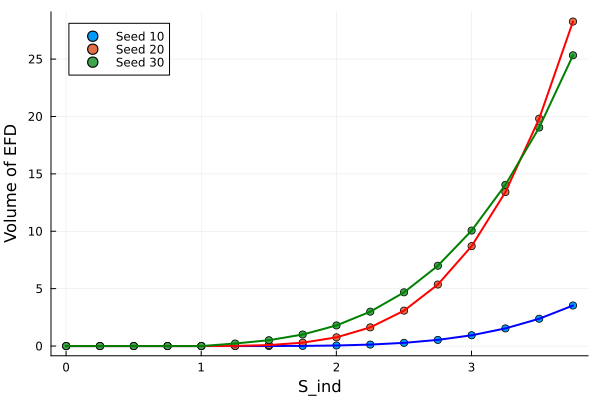

In [9]:
# plot vols vs Sind in log-log plot:
using Plots

plot(Sinds, vols[1], seriestype=:scatter, label="Seed 10", xlabel="S_ind", ylabel="Volume of EFD")
plot!(Sinds, vols[2], seriestype=:scatter, label="Seed 20")
plot!(Sinds, vols[3], seriestype=:scatter, label="Seed 30")

# Add lines on top of scatter points
plot!(Sinds, vols[1], seriestype=:line, lw=2, label="", color=:blue)
plot!(Sinds, vols[2], seriestype=:line, lw=2, label="", color=:red)
plot!(Sinds, vols[3], seriestype=:line, lw=2, label="", color=:green)

In [ ]:
# plot the first and second elements of the trajectories
using Plots

x = [p[1] for p in trajectory]
y = [p[4] for p in trajectory]

scatter(x, y, markersize=2, alpha=0.5, legend=false, title="Sampling s1 and s2",
    xlims=(0, maximum(x)*1.01), ylims=(0, maximum(y)*1.01))